# Outlier Analysis: TLC Trip Metrics

Goal: find genuinely-impossible values in the trip-level metrics (distance, duration, cost, tip)
that survive the existing domain-bound validity rules in `scripts/tlc_trips.py`, and decide whether
new bounds are warranted -- computed over the **full** 2025 valid-trip population (no subsampling;
`scripts/aggregate_distribution_stats.py` uses Spark's `percentile_approx`, an exact-enough
distributed quantile, not a drawn sample), per the project spec's requirement that outlier analysis
use the full distribution, not a subsample.

**Why not just use the mechanical 1.5x-IQR fence as the cutoff?** It finds the tail, but applying it
literally would flag routine, legitimate trips as "outliers" -- shown concretely below. The bounds
actually adopted are read off the real distributions (boxplots) and picked to catch only
genuinely-impossible values, not statistically-unusual-but-real ones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = "../data/processed"
PLOTS_DIR = "../plots"

summary = pd.read_csv(f"{DATA_DIR}/mode_summary_stats_2025.csv").set_index("mode")
outlier_rates = pd.read_csv(f"{DATA_DIR}/mode_outlier_rates_2025.csv").set_index("mode")
MODES = ["yellow", "green", "uber", "lyft"]
summary.loc[MODES]

,n,distance_mean,distance_stddev,duration_min_mean,duration_min_stddev,cost_mean,cost_stddev,tip_mean,tip_stddev,distance_min,...,cost_min,cost_q1,cost_median,cost_q3,cost_max,tip_min,tip_q1,tip_median,tip_q3,tip_max
mode,,,,,,,,,,,,,,,,,,,,,
yellow,42141342,3.359597,4.054458,16.929641,26.054961,28.437222,153.327416,3.087462,3.831128,0.110,...,0.0,16.75,21.90,31.14,863380.37,0.0,0.0,2.50,4.14,960.94
green,489778,2.898874,2.883244,20.954130,91.327251,24.327716,17.056983,2.820428,3.378180,0.110,...,3.5,14.30,19.68,28.15,995.00,0.0,0.0,2.38,4.00,350.00
uber,167672188,4.539182,4.505959,19.083486,13.288195,31.429088,26.355295,1.043346,3.071507,0.110,...,2.5,14.51,22.94,38.46,2442.33,0.0,0.0,0.00,0.00,208.97
lyft,64364060,4.318702,4.229815,18.877552,12.707218,29.207914,22.244781,1.160182,3.070962,0.101,...,2.7,14.69,22.65,35.79,1456.97,0.0,0.0,0.00,0.00,111.75


In [2]:
def tukey_stats(metric, modes=MODES):
    """Build matplotlib bxp() stats dicts from a five-number summary (min,
    q1, median, q3, max) -- the Tukey fence is computed here explicitly so
    it can be shown and then argued against, not silently applied."""
    stats = []
    for m in modes:
        row = summary.loc[m]
        q1, med, q3 = row[f"{metric}_q1"], row[f"{metric}_median"], row[f"{metric}_q3"]
        iqr = q3 - q1
        fence_lo, fence_hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        whislo = max(row[f"{metric}_min"], fence_lo)
        whishi = min(row[f"{metric}_max"], fence_hi)
        stats.append({
            "label": m, "med": med, "q1": q1, "q3": q3,
            "whislo": whislo, "whishi": whishi,
            "fliers": [row[f"{metric}_min"], row[f"{metric}_max"]],
        })
    return stats


def plot_metric(metric, ylabel, title, logscale=True, new_bound=None):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    stats = tukey_stats(metric)
    ax.bxp(stats, showfliers=True)
    if logscale:
        ax.set_yscale("log")
    if new_bound is not None:
        ax.axhline(new_bound, color="crimson", ls="--", lw=1.3,
                    label=f"adopted bound: {new_bound}")
        ax.legend(frameon=False, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.25, lw=0.5, axis="y")
    plt.tight_layout()
    return fig, ax

## Distance -- already well-bounded, no new rule needed

`tlc_trips.py` already enforces `distance in (0.1, 300)` miles at the trip level. The boxplot below
(fliers = population min/max) confirms the *max* observed value sits right at that existing cap for
every mode -- the rule is doing its job, nothing further is warranted here.

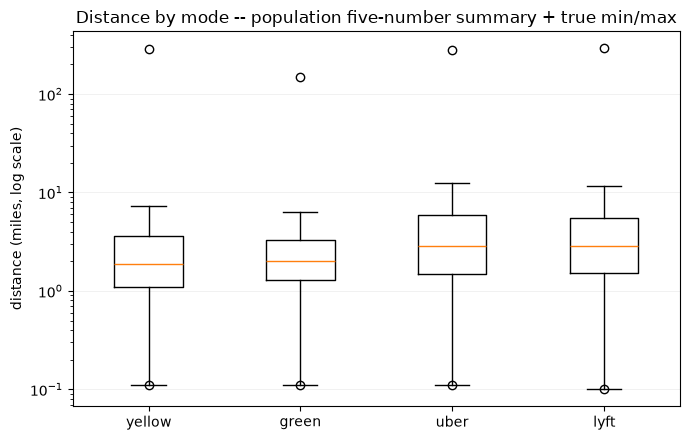

,distance_min,distance_q1,distance_median,distance_q3,distance_max
mode,,,,,
yellow,0.110,1.100,1.860,3.600,290.250
green,0.110,1.300,2.000,3.320,147.400
uber,0.110,1.490,2.830,5.940,278.560
lyft,0.101,1.515,2.827,5.548,291.376


In [3]:
fig, ax = plot_metric("distance", "distance (miles, log scale)",
                      "Distance by mode -- population five-number summary + true min/max")
fig.savefig(f"{PLOTS_DIR}/outlier_distance_boxplot_2025.png", dpi=150, bbox_inches="tight")
plt.show()
summary.loc[MODES, ["distance_min", "distance_q1", "distance_median", "distance_q3", "distance_max"]]

## Duration -- genuinely impossible values found

Yellow taxi's `duration_min_max` is **14,880.8 minutes (~10.3 days)**; green's is 1,439.9 min (~24h).
No existing rule catches this (`tlc_trips.py` only required `duration > 60 seconds`, no upper bound).

**Why not the mechanical fence?** For yellow, `Q3 + 1.5*IQR` computes to about **40 minutes** -- that
would flag a large share of completely ordinary trips (the report's own JFK-trip average is 40.8
minutes) as "outliers". The dashed line below is the bound actually adopted instead: **300 minutes
(5 hours)** -- generous enough that no real NYC trip (even stuck in citywide gridlock, or a paid
waiting-time job) plausibly exceeds it, while still excluding the multi-day "trips" above.

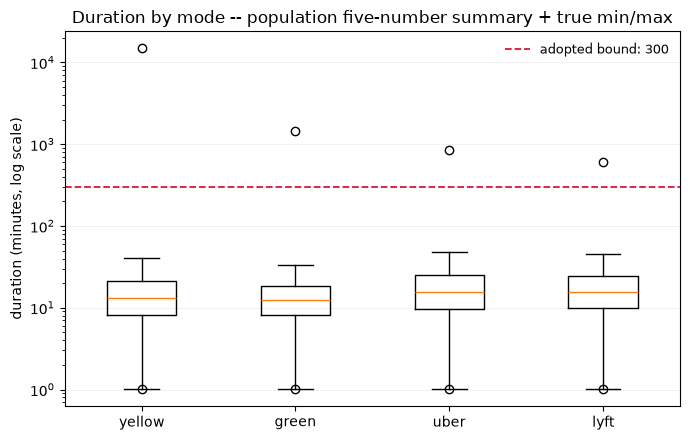

Yellow taxi duration: mechanical upper fence = 40.0 min (would flag the JFK-trip average of 40.8 min as an outlier)
Yellow taxi duration: true max = 14880.8 min
Adopted bound: 300 min -- catches the impossible tail, keeps every plausible real trip


In [4]:
fig, ax = plot_metric("duration_min", "duration (minutes, log scale)",
                      "Duration by mode -- population five-number summary + true min/max",
                      new_bound=300)
fig.savefig(f"{PLOTS_DIR}/outlier_duration_boxplot_2025.png", dpi=150, bbox_inches="tight")
plt.show()
yellow_iqr = summary.loc["yellow", "duration_min_q3"] - summary.loc["yellow", "duration_min_q1"]
yellow_fence = summary.loc["yellow", "duration_min_q3"] + 1.5 * yellow_iqr
print(f"Yellow taxi duration: mechanical upper fence = {yellow_fence:.1f} min "
      f"(would flag the JFK-trip average of 40.8 min as an outlier)")
print(f"Yellow taxi duration: true max = {summary.loc['yellow', 'duration_min_max']:.1f} min")
print(f"Adopted bound: 300 min -- catches the impossible tail, keeps every plausible real trip")

## Cost -- genuinely impossible values found

Yellow taxi's `cost_max` is **\$863,380.37**. No existing rule bounds the total charged amount
(`tlc_trips.py` only required `fare_amount >= $2.50`, a *floor*, not a ceiling).

**Why not the mechanical fence?** For yellow, `Q3 + 1.5*IQR` computes to about **\$53** -- well below
this report's own JFK-trip average fare of \$82.6, so a mechanical fence would flag ordinary airport
trips as outliers. The bound adopted instead is **\$500** -- comfortably above any legitimate
long-haul/airport fare, while excluding values that are off by 3-4 orders of magnitude.

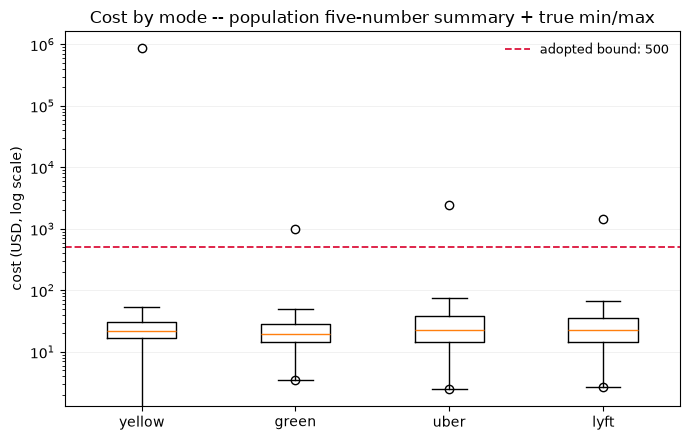

Yellow taxi cost: mechanical upper fence = $52.73 (would flag the JFK-trip average fare of $82.6 as an outlier)
Yellow taxi cost: true max = $863,380.37
Adopted bound: $500 -- catches the impossible tail, keeps every plausible real fare


In [5]:
fig, ax = plot_metric("cost", "cost (USD, log scale)",
                      "Cost by mode -- population five-number summary + true min/max",
                      new_bound=500)
fig.savefig(f"{PLOTS_DIR}/outlier_cost_boxplot_2025.png", dpi=150, bbox_inches="tight")
plt.show()
yellow_iqr_c = summary.loc["yellow", "cost_q3"] - summary.loc["yellow", "cost_q1"]
yellow_fence_c = summary.loc["yellow", "cost_q3"] + 1.5 * yellow_iqr_c
print(f"Yellow taxi cost: mechanical upper fence = ${yellow_fence_c:.2f} "
      f"(would flag the JFK-trip average fare of $82.6 as an outlier)")
print(f"Yellow taxi cost: true max = ${summary.loc['yellow', 'cost_max']:,.2f}")
print(f"Adopted bound: $500 -- catches the impossible tail, keeps every plausible real fare")

## Tip -- not a model feature, so nulled rather than dropped

Tip is not used anywhere in the demand model (see `generate_design_matrix.py`), so an implausible tip
value shouldn't discard an otherwise-valid trip. Extreme values here (yellow max \$960.94) are instead
**nulled in place** -- the trip is kept, only the `tip` field becomes missing. Adopted threshold:
**\$200** (round-number ceiling comfortably above any real tip, well below the extreme tail).

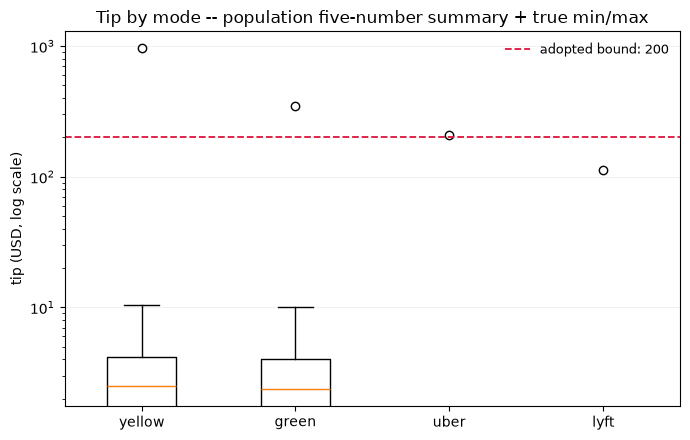

In [6]:
fig, ax = plot_metric("tip", "tip (USD, log scale)",
                      "Tip by mode -- population five-number summary + true min/max",
                      new_bound=200)
fig.savefig(f"{PLOTS_DIR}/outlier_tip_boxplot_2025.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary: rules adopted

| Metric | Existing rule (pre-analysis) | New rule (this notebook) | Action | Enforced in |
|---|---|---|---|---|
| Distance | (0.1, 300) mi | none needed -- already clean | -- | `tlc_trips.py` (unchanged) |
| Duration | > 60 sec | **< 300 min** | drop trip | `tlc_trips.py` `MAX_TRIP_MINUTES` |
| Cost | fare >= \$2.50 (floor only) | **<= \$500** | drop trip | `tlc_trips.py` `MAX_COST` |
| Tip | >= 0 | **> \$200 -> null** | null field, keep trip | `tlc_trips.py` `MAX_PLAUSIBLE_TIP` |

These bounds are centralised in `tlc_trips.load_clean_trips` (the one shared trip-loading function
every pipeline script calls), so `generate_design_matrix.py` -- and therefore the demand model --
sees exactly the same cleaned population this analysis was run against, not a separately-filtered
copy. `data/processed/demand/` was regenerated after these rules were added.

For reference, the table below is the mechanical IQR-fence outlier *rate* per mode/metric
(`aggregate_distribution_stats.py`'s `mode_outlier_rates_2025.csv`) -- shown for completeness, but
**not** what was used to set the bounds above (as demonstrated, that fence is far too aggressive for
this data: e.g. an 11.7% "outlier rate" on yellow distance, most of which are ordinary long trips).

In [7]:
outlier_rates.loc[MODES]

,n,distance_outlier_rate,duration_min_outlier_rate,cost_outlier_rate,tip_outlier_rate
mode,,,,,
yellow,42141342,0.117025,0.052392,0.096569,0.052877
green,489778,0.095956,0.054182,0.070164,0.028088
uber,167672188,0.068258,0.040721,0.068018,0.182372
lyft,64364060,0.067189,0.040880,0.065779,0.201538
